Για τις ανάγκες της προκαταρκτικής αυτής εργασίας έχουν δημιουργηθεί πακέτα κώδικα που χρησιμοποιούνται ως βιβλιοθήκες στη ροή του notebook.

In [4]:
import importlib
import DatasetBuilder
import visualisation_mod
import pandas as pd
import numpy as np
import torch

# Force a fresh load of both modules
importlib.reload(DatasetBuilder)
importlib.reload(visualisation_mod)

from DatasetBuilder import MultimodalDatasetFactory, MultimodalUniverseFactory
from visualisation_mod import UniverseVisualizer
from EDA import ExploratoryAnalyzer

DATA_ROOT = "/content/drive/MyDrive/Data_science_and_applications"
factory = MultimodalUniverseFactory(base_path=DATA_ROOT)
print("✓ Modules synced and ready.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/thinpan/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/home/thinpan/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1043, in launch_instance
    app.start()
  File "/home/thinpan/.local/lib/python3.10/site-

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [ ]:
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

### Data Import and Encoding

As part of the **"Data Science and Applications" (CS485)** course, this project focuses on the analysis of astronomical data retrieved from the **Multimodal Universe** platform.

* **Research Objective:** The core question of this study is the approximation of a star's **Absolute Magnitude ($M$)** in cases where certain parameters are difficult to measure accurately or are missing altogether. Our goal is to derive a new variable that effectively substitutes the independent variables in the absolute magnitude equation using regression models.
* **Data and Variables:** We utilize data from the **Gaia survey**, focusing on the following parameters:
    * $m$ (**Apparent Magnitude**): The observed brightness (`phot_g_mean_mag`).
    * $p$ (**Parallax**): The parallax measured in milliarcseconds (mas).

### Theoretical Challenge and Model Architecture

Our colleagues in the astronomy department have challenged us to approximate a fundamental physical relationship they use daily:
$$M = m - 5 \log_{10}(d) + 5$$

It is worth noting that parallax measurements often carry significant observational errors or even negative values for distant objects. This makes the logarithmic term in the equation mathematically unstable. By using a Neural Network, we aim to learn a robust mapping that can handle these analytical instabilities.

---------------Part 0 - Data Aquisition and Filtering ------------------


In [ ]:
factory = MultimodalUniverseFactory(base_path="MultimodalUniverse/gaia")

df_gaia = factory.load_as_dataframe("MultimodalUniverse/gaia", n_samples=250)

Opening stream to MultimodalUniverse/gaia...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Successfully fetched 250 examples via stream.
Successfully created DataFrame with shape: (250, 73)


(Fellow astronomer):Boy, that dataset does not contain only stars! You've got contaminants and unreliable astrometry in there!

In [ ]:
all_variables = df_gaia.columns.tolist()
df_gaia.describe()

,object_id,healpix,ra,dec,phot_g_mean_mag,phot_g_mean_flux,phot_g_mean_flux_error,phot_bp_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,...,teff_gspphot_lower,teff_gspphot_upper,ruwe,ecl_lat,ecl_lon,nu_eff_used_in_astrometry,pseudocolour,astrometric_params_solved,rv_template_teff,grvs_mag
count,2.500000e+02,250.0,250.000000,250.000000,250.000000,2.500000e+02,250.000000,250.000000,2.500000e+02,250.000000,...,232.000000,232.000000,249.000000,250.000000,250.000000,248.000000,1.000000,250.000000,67.000000,66.000000
mean,4.816502e+13,0.0,45.024903,0.472381,15.586965,1.541679e+05,62.414861,16.183444,7.707946e+04,81.387243,...,4942.759821,4995.647140,1.337507,-15.891450,42.704569,1.463208,1.285669,31.144000,5258.208955,12.271604
std,2.831651e+13,0.0,0.287223,0.185804,1.849637,8.548461e+05,318.900072,1.978973,4.081921e+05,425.356424,...,1251.738919,1287.004015,1.609398,0.178428,0.303386,0.088790,NaN,4.424655,1038.997077,1.677288
min,4.295807e+09,0.0,44.347668,0.005615,8.068802,5.755077e+02,1.915766,8.554075,3.185234e+02,3.905183,...,3416.125488,3435.402344,0.850041,-16.329575,42.070763,1.249905,1.285669,3.000000,3500.000000,7.174999
25%,2.008756e+13,0.0,44.793941,0.337155,14.913305,3.433735e+03,2.988956,15.456477,1.296120e+03,12.434886,...,4321.040039,4370.207886,0.989001,-16.024553,42.463692,1.401820,1.285669,31.000000,4625.000000,11.584083
50%,5.150954e+13,0.0,45.051355,0.494011,16.013763,7.403582e+03,4.373670,16.657527,2.967637e+03,15.666491,...,4951.305420,4998.954834,1.030815,-15.886818,42.674387,1.483192,1.285669,31.000000,5250.000000,13.043884
75%,7.318624e+13,0.0,45.256028,0.618650,16.847957,2.040170e+04,9.185114,17.556932,8.970767e+03,22.932981,...,5403.469116,5454.418945,1.091646,-15.739901,42.935192,1.532099,1.285669,31.000000,5750.000000,13.467542
max,9.573053e+13,0.0,45.676891,0.868359,18.787239,1.115388e+07,3210.559082,19.080688,5.173526e+06,5383.515625,...,18626.841797,19276.490234,21.098814,-15.535777,43.392708,1.765242,1.285669,95.000000,11000.000000,13.943413


### Data Retrieval and Filtering Mechanism

We have upgraded the loading mechanism to ensure that the final feature matrix $X \in \mathbb{R}^{n \times d}$ contains exactly the sample size $n$ specified by the user.

* **Batch-Level Filtering:** The filtering process is executed immediately after retrieving each batch, but before the data is appended to the main DataFrame.
* **Feature Selection:** We employ a filtering tool to retain only the variables typically used by astronomers to calculate absolute magnitude.
* **Key Variables:** * `phot_g_mean_mag` ($m$)
    * `parallax` ($p$)
    * `bp_rp` (Color index)

#### Data Pre-processing
To ensure the integrity of the regression model, we perform the following cleaning steps:
1. **Handling Missing Values:** Removal of all samples containing null values (NaN).
2. **Physical Constraints:** Removal of samples with negative parallax values to maintain mathematical and physical consistency.

In [ ]:
pipeline = ['_apply_star_filters', '_filter_completeness']

df_filtered = factory.load_validated_dataset(
    path="MultimodalUniverse/gaia",
    n_wanted=250,
    batch_size=100,
    filter_names=pipeline
)

print(f"Acquisition complete. Final dataset contains {len(df_filtered)} validated stars.")

Acquisition complete. Final dataset contains 250 validated stars.


In [ ]:
df_filtered.describe()

,object_id,healpix,ra,dec,phot_g_mean_mag,phot_g_mean_flux,phot_g_mean_flux_error,phot_bp_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,...,teff_gspphot_upper,ruwe,ecl_lat,ecl_lon,nu_eff_used_in_astrometry,pseudocolour,astrometric_params_solved,rv_template_teff,grvs_mag,abs_mag
count,2.500000e+02,250.0,250.000000,250.000000,250.000000,2.500000e+02,250.000000,250.000000,2.500000e+02,250.000000,...,241.000000,250.000000,250.000000,250.000000,250.000000,0.0,250.0,60.000000,59.000000,250.000000
mean,5.447587e+13,0.0,44.983778,0.501014,15.677276,1.513874e+05,50.083556,16.260762,7.569627e+04,79.658956,...,4960.247089,1.033688,-15.852035,42.672441,1.467900,NaN,31.0,5300.833333,12.203748,5.713895
std,3.115573e+13,0.0,0.304335,0.194250,1.835618,8.548999e+05,284.016904,1.949702,4.082090e+05,425.348890,...,857.744368,0.087653,0.202823,0.310430,0.084703,NaN,0.0,1057.439010,1.720321,2.190915
min,4.295807e+09,0.0,44.347668,0.005615,8.068802,5.755077e+02,1.915766,8.554075,3.185234e+02,3.905183,...,3444.245605,0.850041,-16.329575,42.070763,1.269860,NaN,31.0,3500.000000,7.174999,-5.151599
25%,2.687898e+13,0.0,44.721073,0.353004,15.083531,3.112871e+03,2.785571,15.574299,1.211226e+03,12.310702,...,4417.202637,0.984012,-15.998914,42.420545,1.410728,NaN,31.0,4750.000000,11.290168,4.540937
50%,5.855114e+13,0.0,44.994667,0.528879,16.167942,6.424470e+03,4.032376,16.713357,2.819017e+03,15.001997,...,5048.869629,1.024931,-15.846677,42.634405,1.487186,NaN,31.0,5250.000000,12.897164,5.649290
75%,8.156250e+13,0.0,45.222001,0.651728,16.954465,1.744014e+04,7.451062,17.630609,8.048318e+03,22.630553,...,5477.346680,1.063751,-15.685310,42.903991,1.532876,NaN,31.0,5750.000000,13.465945,7.093924
max,1.029804e+14,0.0,45.676891,0.868359,18.787239,1.115388e+07,3210.559082,19.080688,5.173526e+06,5383.515625,...,12370.715820,1.398988,-15.473042,43.392708,1.765242,NaN,31.0,11000.000000,13.943413,10.812217


### Visualizing the "Astronomer's Filter"

For demonstration purposes, the distributions of the variables before and after applying the **"Astronomer's Filter"** are compared below.

To quantify the difference between the initial (unfiltered) data stream and our verified stellar sample, we calculate the **Kolmogorov-Smirnov (K-S) Statistic**. This allows us to statistically measure how much the distribution has shifted after removing non-physical values and outliers.

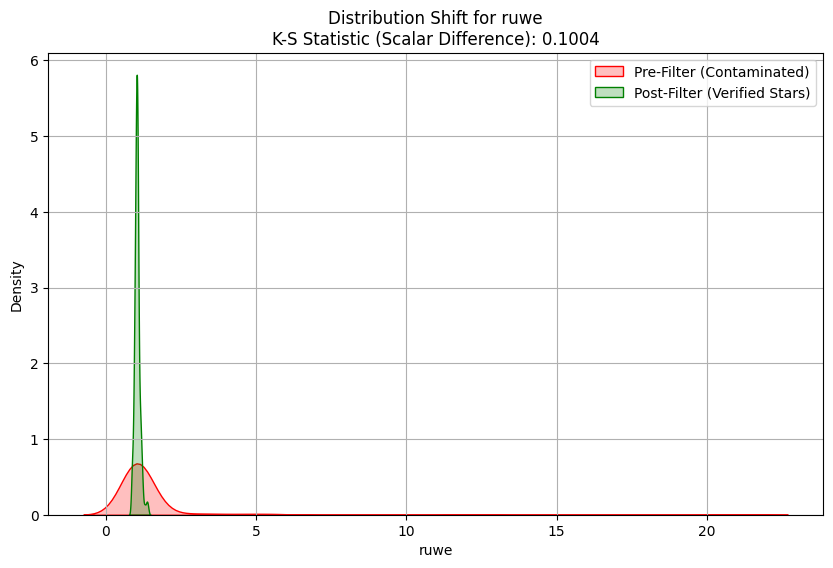

In [ ]:
def demonstrate_filter_impact(df_raw, df_filtered, column='ruwe'):
    """
    Calculates the K-S statistic to represent the difference between
    distributions and visualizes the change.
    """
    # 1. Calculate the Scalar Difference (K-S Statistic)
    # The result 'd_stat' is a scalar between 0 and 1
    d_stat, p_value = ks_2samp(df_raw[column].dropna(), df_filtered[column])

    # 2. Visualization
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df_raw[column], label='Pre-Filter (Contaminated)', fill=True, color='red')
    sns.kdeplot(df_filtered[column], label='Post-Filter (Verified Stars)', fill=True, color='green')

    plt.title(f"Distribution Shift for {column}\nK-S Statistic (Scalar Difference): {d_stat:.4f}")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()
    plt.grid()
    plt.show()

    return d_stat

ruwe_diff = demonstrate_filter_impact(df_gaia, df_filtered, column='ruwe')

#### The `DistanceModulusNet`
To address this, we have designed a Multi-Layer Perceptron (MLP) specifically for this regression task.

* **Input Layer:** Receives 2 features ($m$ and $p$).
* **Hidden Layers:** Utilize **ReLU** activation functions. These are essential for capturing the non-linear logarithmic behavior of the parallax within the distance modulus formula.
* **Output Layer:** A single continuous value representing the predicted **Absolute Magnitude ($M$)**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X_raw = df_filtered[['phot_g_mean_mag', 'parallax']].values
y_raw = df_filtered['abs_mag'].values.reshape(-1, 1)

# (80/20)
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

print(f"Scaled X_train sample:\n{X_train[:3]}")
print(f"Target y_train sample:\n{y_train[:3]}")

Scaled X_train sample:
tensor([[-0.1217, -0.4237],
        [ 0.8202, -0.7009],
        [ 0.3875,  1.7145]])
Target y_train sample:
tensor([[4.8302],
        [4.0270],
        [9.8038]])


In [ ]:
class DistanceModulusNet(nn.Module):
    """
    A simple neural network to approximate the distance modulus equation.
    It learns the mapping from (m, p) -> M.
    """
    def __init__(self):
        super(DistanceModulusNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 16),      # Input: m, parallax
            nn.ReLU(),             # Non-linear activation to capture log(p)
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)        # Output: Predicted abs_mag
        )
    def forward(self, x):
        return self.network(x)

    def save_weights(self, path: str = "distance_model.pth"):
        """Saves the learned internal weights (state_dict) to disk."""
        torch.save(self.state_dict(), path)
        print(f"Model weights successfully saved to {path}")

    @staticmethod
    def load_from_weights(path: str):
        """Creates a new model instance and populates it with saved weights."""
        model = DistanceModulusNet()
        model.load_state_dict(torch.load(path))
        model.eval()  # Set to evaluation mode by default after loading
        print(f"Model loaded from {path} and set to evaluation mode.")
        return model

In [ ]:
model = DistanceModulusNet()
criterion = nn.MSELoss() # Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 3000
train_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

print(f"Training completed with Loss: {train_losses[-1]}")

Training completed with Loss: 0.006756121292710304


In [ ]:
# model.save_weights("models/gaia_nn_v1.pth")

# fresh_model = DistanceModulusNet.load_from_weights("gaia_nn_v1.pth")

In [ ]:
# Downloading 100 fresh samples using our validated pipeline
df_stars = factory.load_validated_dataset(
    path="MultimodalUniverse/gaia",
    n_wanted=250,
    batch_size=50,
    filter_names=['_apply_star_filters', '_filter_completeness']
)

X_new_raw = df_stars[['phot_g_mean_mag', 'parallax']].values
y_new_true = df_stars['abs_mag'].values.reshape(-1, 1)

# Use the SAME scaler we used during training
X_new_scaled = scaler.transform(X_new_raw)
X_new_tensor = torch.tensor(X_new_scaled, dtype=torch.float32)
y_new_tensor = torch.tensor(y_new_true, dtype=torch.float32)

In [ ]:
len(df_stars.columns)

74

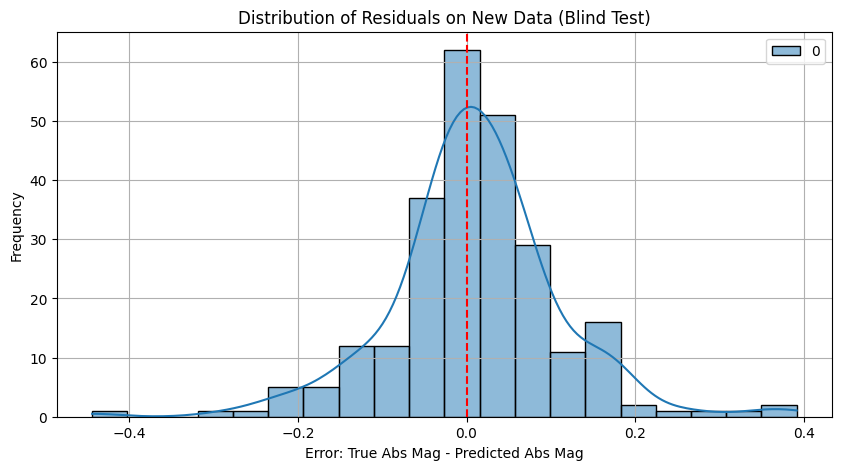

In [ ]:
# Get model predictions
model.eval()
with torch.no_grad():
    y_new_pred = model(X_new_tensor).numpy()

residuals = y_new_true - y_new_pred

# the Distribution of Residuals
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=20)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Residuals on New Data (Blind Test)')
plt.xlabel('Error: True Abs Mag - Predicted Abs Mag')
plt.ylabel('Frequency')
plt.grid()
plt.show()

We have a solid baseline. We now have a neural version of the physics. It’s our ground truth. Ready for the Real Test: Since the model can replicate the known formula ($M = m + 5 + 5 \log_{10}(p/1000)$), we can stop relying on distance ($d$) and start hunting for other variables that can do the same job.

-> Sensor Substitution: Using expensive sensors (Parallax/LIDAR) to train a model that eventually only uses cheap sensors (Color indices/RGB cameras).

Part 1 — Exploratory Data Analysis

---



## Feature Correlation Analysis (Feature Discovery)

In this section, we examine which of the available Gaia variables exhibit the greatest "alignment" with Absolute Magnitude ($M$) in multidimensional space.

### Methodology

* **Cosine Similarity:** We measure the angle between the vector of each feature and the target vector $\mathbf{y}$. A value near $1$ indicates that the variable "points" in the same direction as $M$.
    $$\cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$

* **Inner Products:** We utilize tensor inner products to identify which features carry the most information regarding the variance of the target.
    $$\langle \mathbf{x}, \mathbf{y} \rangle = \sum_{i=1}^{n} x_i y_i$$

In [ ]:
def fast_statistical_cleanup(df, target_col):
    """
    Removing constant and sparse features
    using basic descriptive statistics.
    """
    numeric_df = df.select_dtypes(include=[np.number])

    # Υπολογισμός Διακύμανσης (Variance) - Εντοπισμός σταθερών τιμών
    variances = numeric_df.var()
    constant_features = variances[variances == 0].index.tolist()

    # (NaN Check) [cite: 18]
    null_counts = numeric_df.isnull().mean()
    sparse_features = null_counts[null_counts > 0.2].index.tolist()

    to_drop = list(set(constant_features + sparse_features))
    cleaned_df = numeric_df.drop(columns=to_drop)

    print(f"--- Statistical Cleanup Report ---")
    print(f" > Removed {len(constant_features)} constant features.")
    print(f" > Removed {len(sparse_features)} sparse features (too many NaNs).")
    print(f" > Remaining candidates for tensor analysis: {cleaned_df.shape[1]}")

    return cleaned_df

df_candidates = fast_statistical_cleanup(df_stars, 'abs_mag')

--- Statistical Cleanup Report ---
 > Removed 2 constant features.
 > Removed 8 sparse features (too many NaNs).
 > Remaining candidates for tensor analysis: 63


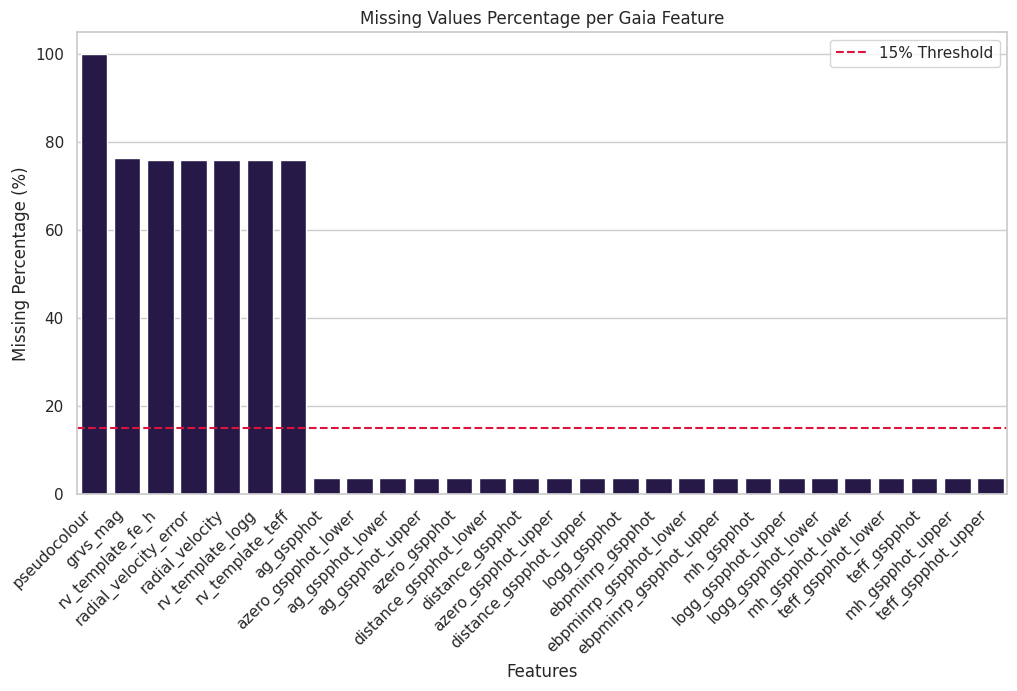

Data Profiling: 29 features contain missing values.


In [ ]:
visualizer = UniverseVisualizer(df_stars)
visualizer.plot_missing_values(threshold=15)

Dropped 8 variables with >15% missing values.
Remaining features for analysis: 67


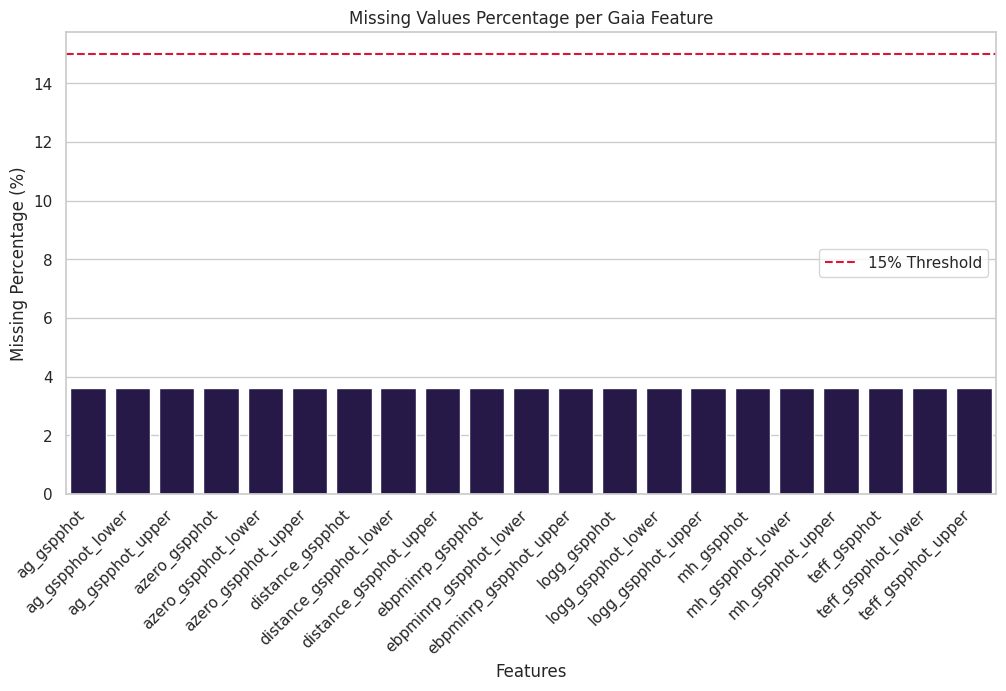

Data Profiling: 21 features contain missing values.


In [ ]:
def drop_insufficient_features(df, threshold=15):
    """
    Removes columns from the DataFrame that exceed the missing value threshold.
    """
    missing_pct = (df.isnull().sum() / len(df)) * 100
    insufficient_cols = missing_pct[missing_pct > threshold].index.tolist()

    clean_df = df.drop(columns=insufficient_cols)

    print(f"Dropped {len(insufficient_cols)} variables with >{threshold}% missing values.")
    print(f"Remaining features for analysis: {clean_df.shape[1]}")
    return clean_df

# Εκτέλεση καθαρισμού στο dataset των 250 αστέρων
df_stars = drop_insufficient_features(df_stars, threshold=15)
visualizer = UniverseVisualizer(df_stars)
visualizer.plot_missing_values(threshold=15)

In [ ]:
len(df_stars.columns)

67

**Principal Component Analysis (PCA)** allows us to identify which variables "contribute" most to the first principal component ($PC_1$). If $PC_1$ correlates strongly with absolute magnitude ($M$), then the parameters composing it are the most valuable for our feature engineering.

In this context, PCA serves as an **information filter**. If photometric proxies like `bp_rp` and `phot_g_mean_mag` dominate the loadings of a $PC_1$ that tracks closely with $M$, we have mathematical confirmation that the **Oracle's** knowledge can be effectively substituted by these features.

In [ ]:
from EDA import ExploratoryAnalyzer

In [ ]:
analysis_df = df_stars.drop(columns=['abs_mag'], errors='ignore')
analyzer = ExploratoryAnalyzer(analysis_df)

# Sequential Analysis
analyzer.get_descriptive_stats()
pca_model, loadings, _ = analyzer.perform_pca(n_components=2)
sim_matrix = analyzer.compute_similarity(n_subset=100)

NameError: name 'df_stars' is not defined

In [ ]:
def auto_discover_features_optimized(df, target_col, threshold=0.9):
    """
    Optimized feature discovery:
    1. Removes zero-variance (constant) features.
    2. Removes sparse features (high NaN ratio).
    3. Computes Cosine Similarity only for relevant candidates.
    """
    # --- Step 1: Statistical Pre-filtering ---
    # Κρατάμε μόνο αριθμητικές στήλες
    numeric_df = df.select_dtypes(include=[np.number])

    # Αφαίρεση στηλών με μηδενική διακύμανση (δεν προσφέρουν πληροφορία)
    variances = numeric_df.var()
    non_constant_cols = variances[variances > 0].index.tolist()

    # Αφαίρεση στηλών με πολλά NaNs (>10%)
    null_ratios = numeric_df[non_constant_cols].isnull().mean()
    viable_cols = null_ratios[null_ratios < 0.1].index.tolist()

    if target_col in viable_cols: viable_cols.remove(target_col)

    # --- Step 2: Tensor-based Similarity ---
    # Προετοιμασία Target Tensor y
    y_vec = torch.tensor(df[target_col].values, dtype=torch.float32).reshape(-1, 1)
    y_norm = y_vec / torch.norm(y_vec)

    selected_features = []
    print(f"{'Variable Name':<30} | {'Similarity Score':<20}")
    print("-" * 55)

    for col in viable_cols:
        # Μετατροπή σε Tensor (γρήγορη πράξη πλέον)
        x_vec = torch.tensor(df[col].values, dtype=torch.float32).reshape(-1, 1)
        x_norm = x_vec / torch.norm(x_vec)

        # Υπολογισμός Cosine Similarity
        similarity = torch.mm(x_norm.t(), y_norm).item()

        # Κρατάμε μόνο όσες έχουν απόλυτη συσχέτιση πάνω από το threshold
        if abs(similarity) > threshold:
            selected_features.append(col)
            print(f"{col:<30} | {similarity:>15.4f}  [SELECTED]")

    return selected_features

# Εκτέλεση της βελτιστοποιημένης διαδικασίας
highly_correlated_vars = auto_discover_features_optimized(df_stars, 'abs_mag', threshold=0.9)

print(f"\nΤελικό Feature Set για το Regression: {highly_correlated_vars}")

Variable Name                  | Similarity Score    
-------------------------------------------------------


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x500 and 250x1)

In [ ]:
# Εκτέλεση σε ολόκληρο το DataFrame των επαληθευμένων αστέρων
highly_correlated_vars = auto_discover_features(df_stars, 'abs_mag', threshold=0.9)

print(f"\nFinal Feature Set for Regression: {highly_correlated_vars}")

NameError: name 'auto_discover_features' is not defined

In [ ]:
features = ['phot_g_mean_mag', 'bp_rp']
X_raw = df_stars[features].values
y_raw = df_stars['abs_mag'].values

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32).reshape(-1, 1)

print(f"--- Tensor Shapes for Regression ---")
print(f"X_train: {X_train.shape} (Samples x Features)")
print(f"y_train: {y_train.shape} (Target)")

--- Tensor Shapes for Regression ---
X_train: torch.Size([200, 2]) (Samples x Features)
y_train: torch.Size([200, 1]) (Target)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# --- 3.2 Similarity & Inner Products ---
# Επιλογή υποσυνόλου 50-100 αντικειμένων για το heatmap
subset_size = min(100, X.shape[0])
X_subset = X[:subset_size]

NameError: name 'X' is not defined

In [ ]:


def compute_tensor_similarities(df, feature_cols, target_col):
    """
    Υπολογίζει την ομοιότητα (Cosine Similarity) μεταξύ των features και του target
    χρησιμοποιώντας PyTorch tensors.
    """
    # Μετατροπή σε Tensors
    X_tensor = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_tensor = torch.tensor(df[target_col].values, dtype=torch.float32).reshape(-1, 1)

    # Κανονικοποίηση (L2 Norm) για τον υπολογισμό Cosine Similarity
    X_norm = X_tensor / X_tensor.norm(dim=0, keepdim=True)
    y_norm = y_tensor / y_tensor.norm(dim=0, keepdim=True)

    # Υπολογισμός ομοιότητας: (X^T * y)
    # Το αποτέλεσμα δείχνει πόσο "ευθυγραμμισμένο" είναι κάθε feature με το M
    similarities = torch.mm(X_norm.t(), y_norm).flatten().tolist()

    # Αποθήκευση των αποτελεσμάτων σε ένα λεξικό για το Discussion
    sim_results = dict(zip(feature_cols, similarities))

    print("--- Feature Similarity to Absolute Magnitude (M) ---")
    for feat, val in sim_results.items():
        print(f" > {feat}: {val:.4f}")
        # Δημιουργία νέας μεταβλητής στο df που αντιπροσωπεύει τη 'σχετική' συνεισφορά
        df[f'sim_score_{feat}'] = df[feat] * val

    return df, sim_results

# Εκτέλεση
df_final, similarity_map = compute_tensor_similarities(df_final, ['phot_g_mean_mag', 'bp_rp'], 'y_target')

NameError: name 'df_final' is not defined

In [ ]:
# 2. Καθαρισμός δεδομένων (Pre-processing)
# Αφαιρούμε τιμές που θα οδηγούσαν σε σφάλμα στον λογάριθμο (p > 0)
df_clean = df_gaia.dropna(subset=['phot_g_mean_mag', 'parallax', 'bp_rp']).copy()
df_clean = df_clean[df_clean['parallax'] > 0]

In [ ]:

# 3. Ορισμός Target Vector y (Absolute Magnitude M)
# Τύπος: M = m + 5 + 5 * log10(p/1000)
df_clean['absolute_magnitude'] = (
    df_clean['phot_g_mean_mag'] + 5 + 5 * np.log10(df_clean['parallax'] / 1000.0)
)
y = df_clean['absolute_magnitude'].values

# 4. Ορισμός Data Matrix X
# Επιλέγουμε τα features: m (apparent mag) και bp_rp (color) ως proxy
X_df = df_clean[['phot_g_mean_mag', 'bp_rp']]
X = X_df.values

# 5. Output Shapes & Representation
print(f"Σχήμα πίνακα δεδομένων X: {X.shape}") # [n_samples, d_features]
print(f"Σχήμα διανύσματος στόχου y: {y.shape}")
print(f"Features (d): {list(X_df.columns)}")

In [ ]:
sample_df = factory.load_as_dataframe("MultimodalUniverse/gaia","train", n_samples=10)

In [ ]:
# Test: Peek at raw data values for the keys we are filtering on
print("--- Gaia Stream Diagnostic ---")
ds = factory.get_streaming_examples("MultimodalUniverse/gaia", split='train')
sample_batch = []
it = iter(ds)

for i in range(3):
    item = next(it)
    print(f"\nItem {i} Data:")
    print(f" > 'parallax': {item.get('parallax')} (Type: {type(item.get('parallax'))})")
    print(f" > 'ruwe': {item.get('ruwe')} (Type: {type(item.get('ruwe'))})")
    print(f" > 'phot_g_mean_mag': {item.get('phot_g_mean_mag')}")
    # Check if the keys we used for Legacy Survey even exist here
    print(f" > 'type' exists?: {'type' in item}")
    print(f" > 'shape_r' exists?: {'shape_r' in item}")

In [ ]:
# Check the root keys of the first item
print(f"Root keys in Gaia item: {ds[0].keys()}")